In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.5

WINDOWS = {
    "9798_6253": (9798, 6253)
    #"6182_3842": (6182, 3842)
    #"3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_univariante_exp_paper(serie):
    """
    Implementa el stationary bootstrap exactamente como en el paper:
    - Usa serie duplicada para permitir bloques que crucen el final
    - Los bloques son siempre contiguos en el tiempo
    """
    n = len(serie)
    # Duplicar la serie para permitir cruce del final sin usar módulo
    serie_period = np.concatenate((serie, serie))
    
    resultado = np.array([])
    
    while len(resultado) < n:
        # Generar longitud de bloque (exponencial con media = n)
        L = int(np.random.exponential(scale=n))
        while L > n:  # Asegurar que L no exceda n
            L = int(np.random.exponential(scale=n))
        
        # Punto de inicio aleatorio (0 a n-1)
        inicio = np.random.randint(0, n)
        
        # Calcular cuántos puntos necesitamos aún
        restantes = n - len(resultado)
        L_actual = min(L, restantes)
        
        # Extraer bloque contiguo de serie_period
        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))
    
    return resultado

def generar_bootstrap_df(df, columnas):
    """
    Genera un dataframe bootstrap usando stationary bootstrap
    """
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_univariante_exp_paper(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2, return_zero_on_fail=True):
    """
    Calcula el coeficiente de Granger sp1 -> sp2
    Si falla, retorna 0 (como en el paper)
    """
    # añadir condicionales (temperatura y multipliers)
    try:
        x = df[sp1].values
        y = df[sp2].values
        temp = df["Temperatura"].values
        mult = df["Multiplier"].values

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(temp) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Temp": temp,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)
        
        coef = results.coefs[0][1][0]  # sp1 -> sp2
        
        return float(coef)

    except Exception as e:
        return 0.0  # Como en el paper, retornar 0 si falla

# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_delta_mult.pkl", "rb") as f:
    df_original = pickle.load(f)

# Invertir orden temporal (cal BP va de mayor a menor = más antiguo a más reciente)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c != "cal BP"]

df_original[especies_cols] = df_original[especies_cols].where(
    df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
)

# Identificar especies válidas en toda la serie
especies_globales = [
    sp for sp in especies_cols
    if es_serie_valida(df_original[sp])
]

print(f"Especies válidas en serie completa: {len(especies_globales)}")

np.random.seed(42)

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")

boot_dfs = [
    generar_bootstrap_df(df_original, especies_globales)
    for _ in range(N_BOOTSTRAP)
]

print(f"{N_BOOTSTRAP} bootstraps generados.")

# =====================================================
# ANÁLISIS POR VENTANAS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # Especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_globales
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    # Extraer ventanas de los bootstraps
    boot_windows = [
        extraer_ventana(df_b, cmin, cmax)
        for df_b in boot_dfs
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pvalor = np.full((n_w, n_w), np.nan)

    total_pairs = 0
    valid_original = 0
    bootstrap_fail = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP SOBRE PARES DE ESPECIES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):
            if i == j:
                continue

            total_pairs += 1

            # Coeficiente original
            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)
            matriz_coef[i, j] = coef_original

            # Coeficientes bootstrap
            coefs_boot = []
            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                coefs_boot.append(coef_boot)  # Siempre añadimos (retorna 0 si falla)

            coefs_boot = np.array(coefs_boot)
            valid_original += 1

            # Verificar si hay suficientes boots NO CERO para tener varianza
            if np.std(coefs_boot) < MIN_VAR:
                bootstrap_fail += 1
                # Si todos los boots son iguales (ej. todos 0), no podemos calcular p-valor
                matriz_pvalor[i, j] = 1.0
                continue

            # =====================================================
            # CÁLCULO DEL P-VALOR BOOTSTRAP (MÉTODO DEL PAPER)
            # =====================================================
            # p-valor = (número de boots con |coef| >= |coef_original| + 1) / (nboots + 1)
            
            n_extremos = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_valor = (n_extremos + 1) / (len(coefs_boot) + 1)
            matriz_pvalor[i, j] = p_valor

            # Decisión de significancia
            if p_valor < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                else:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    print("\n--- DIAGNÓSTICO ---")
    print(f"Pares totales evaluados: {total_pairs}")
    print(f"Pares con coeficiente válido: {valid_original} ({valid_original/total_pairs*100:.2f}%)")

    if valid_original > 0:
        print(f"Pares sin varianza en bootstrap: {bootstrap_fail} ({bootstrap_fail/valid_original*100:.2f}% de válidos)")
        print(f"\nSignificativos (p < {ALPHA}): {n_sig} ({n_sig/valid_original*100:.2f}% de válidos)")
        print(f"  Negativos (cola baja): {n_low} ({n_low/n_sig*100:.1f}% de significativos)")
        print(f"  Positivos (cola alta): {n_high} ({n_high/n_sig*100:.1f}% de significativos)")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pvalor,
        "n_bootstrap": N_BOOTSTRAP,
        "alpha": ALPHA
    }

    nombre_archivo = f"red_granger_{window_name}_def.pkl"
    with open(nombre_archivo, "wb") as f:
        pickle.dump(resultado, f)

    print(f"\nGuardado: {nombre_archivo}")

print("\nProceso terminado correctamente.")

Especies válidas en serie completa: 69

Generando bootstrap...
300 bootstraps generados.

VENTANA: 9798_6253
Tamaño ventana: 51 observaciones
Especies válidas en ventana: 58

--- DIAGNÓSTICO ---
Pares totales evaluados: 3306
Pares con coeficiente válido: 3306 (100.00%)
Pares sin varianza en bootstrap: 0 (0.00% de válidos)

Significativos (p < 0.05): 309 (9.35% de válidos)
  Negativos (cola baja): 91 (29.4% de significativos)
  Positivos (cola alta): 218 (70.6% de significativos)

Guardado: red_granger_9798_6253.pkl

Proceso terminado correctamente.


In [56]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.5

WINDOWS = {
    #"9798_6253": (9798, 6253)
    "6182_3842": (6182, 3842)
    #"3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    return (serie > 0).sum() >= MIN_PRESENCIA 

# def bootstrap_univariante_exp_paper(serie):
    """
    Implementa el stationary bootstrap exactamente como en el paper:
    - Usa serie duplicada para permitir bloques que crucen el final
    - Los bloques son siempre contiguos en el tiempo
    """
    n = len(serie)
    # Duplicar la serie para permitir cruce del final sin usar módulo
    serie_period = np.concatenate((serie, serie))
    
    resultado = np.array([])
    
    while len(resultado) < n:
        # Generar longitud de bloque (exponencial con media = n)
        L = int(np.random.exponential(scale=n))
        while L > n:  # Asegurar que L no exceda n
            L = int(np.random.exponential(scale=n))
        
        # Punto de inicio aleatorio (0 a n-1)
        inicio = np.random.randint(0, n)
        
        # Calcular cuántos puntos necesitamos aún
        restantes = n - len(resultado)
        L_actual = min(L, restantes)
        
        # Extraer bloque contiguo de serie_period
        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))
    
    return resultado

def bootstrap_univariante_exp_paper(serie):

    n = len(serie)
    resultado = []

    while len(resultado) < n:

        inicio = np.random.randint(0, n)
        longitud=n+1
        while longitud>n:
            longitud = int(np.random.exponential(scale=n))
        longitud = max(1, min(longitud, n))

        indices = (inicio + np.arange(longitud)) % n
        resultado.extend(serie[indices])

    return np.array(resultado[:n])



def generar_bootstrap_df(df, columnas):
    """
    Genera un dataframe bootstrap usando stationary bootstrap
    """
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values

    for col in columnas:
        df_boot[col] = bootstrap_univariante_exp_paper(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2, return_zero_on_fail=True):
    """
    Calcula el coeficiente de Granger sp1 -> sp2
    Si falla, retorna 0 (como en el paper)
    """
    try:
        x = df[sp1].values
        y = df[sp2].values

        if np.std(x) < MIN_VAR or np.std(y) < MIN_VAR:
            return 0.0

        data = pd.DataFrame({sp1: x, sp2: y})
        model = VAR(data)
        results = model.fit(maxlags=1)
        
        coef = results.coefs[0][1][0]  # sp1 -> sp2
        
        return float(coef)

    except Exception as e:
        return 0.0  # Como en el paper, retornar 0 si falla

# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam.pkl", "rb") as f:
    df_original = pickle.load(f)

# Invertir orden temporal (cal BP va de mayor a menor = más antiguo a más reciente)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c != "cal BP"]

df_original[especies_cols] = df_original[especies_cols].where(
    df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
)

# Identificar especies válidas en toda la serie
especies_globales = [
    sp for sp in especies_cols
    if es_serie_valida(df_original[sp])
]

print(f"Especies válidas en serie completa: {len(especies_globales)}")

np.random.seed(42)

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")

boot_dfs = [
    generar_bootstrap_df(df_original, especies_globales)
    for _ in range(N_BOOTSTRAP)
]

print(f"{N_BOOTSTRAP} bootstraps generados.")

# =====================================================
# ANÁLISIS POR VENTANAS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # Especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_globales
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    # Extraer ventanas de los bootstraps
    boot_windows = [
        extraer_ventana(df_b, cmin, cmax)
        for df_b in boot_dfs
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pvalor = np.full((n_w, n_w), np.nan)

    total_pairs = 0
    valid_original = 0
    bootstrap_fail = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP SOBRE PARES DE ESPECIES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):
            if i == j:
                continue

            total_pairs += 1

            # Coeficiente original
            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)
            matriz_coef[i, j] = coef_original

            # Coeficientes bootstrap
            coefs_boot = []
            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                coefs_boot.append(coef_boot)  # Siempre añadimos (retorna 0 si falla)

            coefs_boot = np.array(coefs_boot)
            valid_original += 1

            # Verificar si hay suficientes boots NO CERO para tener varianza
            if np.std(coefs_boot) < MIN_VAR:
                bootstrap_fail += 1
                # Si todos los boots son iguales (ej. todos 0), no podemos calcular p-valor
                matriz_pvalor[i, j] = 1.0
                continue

            # =====================================================
            # CÁLCULO DEL P-VALOR BOOTSTRAP (MÉTODO DEL PAPER)
            # =====================================================
            # p-valor = (número de boots con |coef| >= |coef_original| + 1) / (nboots + 1)
            
            n_extremos = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_valor = (n_extremos + 1) / (len(coefs_boot) + 1)
            matriz_pvalor[i, j] = p_valor

            # Decisión de significancia
            if p_valor < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                else:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    print("\n--- DIAGNÓSTICO ---")
    print(f"Pares totales evaluados: {total_pairs}")
    print(f"Pares con coeficiente válido: {valid_original} ({valid_original/total_pairs*100:.2f}%)")

    if valid_original > 0:
        print(f"Pares sin varianza en bootstrap: {bootstrap_fail} ({bootstrap_fail/valid_original*100:.2f}% de válidos)")
        print(f"\nSignificativos (p < {ALPHA}): {n_sig} ({n_sig/valid_original*100:.2f}% de válidos)")
        print(f"  Negativos (cola baja): {n_low} ({n_low/n_sig*100:.1f}% de significativos)")
        print(f"  Positivos (cola alta): {n_high} ({n_high/n_sig*100:.1f}% de significativos)")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pvalor,
        "n_bootstrap": N_BOOTSTRAP,
        "alpha": ALPHA
    }

    nombre_archivo = f"red_granger_{window_name}.pkl"
    with open(nombre_archivo, "wb") as f:
        pickle.dump(resultado, f)

    print(f"\nGuardado: {nombre_archivo}")

print("\nProceso terminado correctamente.")

Especies válidas en serie completa: 74

Generando bootstrap...
300 bootstraps generados.

VENTANA: 6182_3842
Tamaño ventana: 33 observaciones
Especies válidas en ventana: 62

--- DIAGNÓSTICO ---
Pares totales evaluados: 3782
Pares con coeficiente válido: 3782 (100.00%)
Pares sin varianza en bootstrap: 0 (0.00% de válidos)

Significativos (p < 0.05): 213 (5.63% de válidos)
  Negativos (cola baja): 73 (34.3% de significativos)
  Positivos (cola alta): 140 (65.7% de significativos)

Guardado: red_granger_6182_3842.pkl

Proceso terminado correctamente.


In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.9

WINDOWS = {
    #"9798_6253": (9798, 6253)
    "6182_3842": (6182, 3842)
    #"3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_univariante_exp_paper(serie):
    """
    Implementa el stationary bootstrap exactamente como en el paper:
    - Usa serie duplicada para permitir bloques que crucen el final
    - Los bloques son siempre contiguos en el tiempo
    """
    n = len(serie)
    # Duplicar la serie para permitir cruce del final sin usar módulo
    serie_period = np.concatenate((serie, serie))
    
    resultado = np.array([])
    
    while len(resultado) < n:
        # Generar longitud de bloque (exponencial con media = n)
        L = int(np.random.exponential(scale=n))
        while L > n:  # Asegurar que L no exceda n
            L = int(np.random.exponential(scale=n))
        
        # Punto de inicio aleatorio (0 a n-1)
        inicio = np.random.randint(0, n)
        
        # Calcular cuántos puntos necesitamos aún
        restantes = n - len(resultado)
        L_actual = min(L, restantes)
        
        # Extraer bloque contiguo de serie_period
        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))
    
    return resultado

def generar_bootstrap_df(df, columnas):
    """
    Genera un dataframe bootstrap usando stationary bootstrap
    """
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values

    for col in columnas:
        df_boot[col] = bootstrap_univariante_exp_paper(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2, return_zero_on_fail=True):
    """
    Calcula el coeficiente de Granger sp1 -> sp2
    Si falla, retorna 0 (como en el paper)
    """
    try:
        x = df[sp1].values
        y = df[sp2].values

        if np.std(x) < MIN_VAR or np.std(y) < MIN_VAR:
            return 0.0

        data = pd.DataFrame({sp1: x, sp2: y})
        model = VAR(data)
        results = model.fit(maxlags=1)
        
        coef = results.coefs[0][1][0]  # sp1 -> sp2
        
        return float(coef)

    except Exception as e:
        return 0.0  # Como en el paper, retornar 0 si falla

# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam.pkl", "rb") as f:
    df_original = pickle.load(f)

# Invertir orden temporal (cal BP va de mayor a menor = más antiguo a más reciente)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c != "cal BP"]

df_original[especies_cols] = df_original[especies_cols].where(
    df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
)

# Identificar especies válidas en toda la serie
especies_globales = [
    sp for sp in especies_cols
    if es_serie_valida(df_original[sp])
]

print(f"Especies válidas en serie completa: {len(especies_globales)}")

np.random.seed(42)

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")

boot_dfs = [
    generar_bootstrap_df(df_original, especies_globales)
    for _ in range(N_BOOTSTRAP)
]

print(f"{N_BOOTSTRAP} bootstraps generados.")

# =====================================================
# ANÁLISIS POR VENTANAS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # Especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_globales
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    # Extraer ventanas de los bootstraps
    boot_windows = [
        extraer_ventana(df_b, cmin, cmax)
        for df_b in boot_dfs
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pvalor = np.full((n_w, n_w), np.nan)
    matriz_mean = np.full((n_w, n_w), np.nan)
    matriz_std = np.full((n_w, n_w), np.nan)

    total_pairs = 0
    valid_original = 0
    bootstrap_fail = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP SOBRE PARES DE ESPECIES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):
            if i == j:
                continue

            total_pairs += 1

            # Coeficiente original
            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)
            matriz_coef[i, j] = coef_original

            # Coeficientes bootstrap
            coefs_boot = []
            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                coefs_boot.append(coef_boot)  # Siempre añadimos (retorna 0 si falla)

            coefs_boot = np.array(coefs_boot)
            valid_original += 1

            matriz_mean[i, j] = np.mean(coefs_boot)
            matriz_std[i, j] = np.std(coefs_boot)

            # Verificar si hay suficientes boots NO CERO para tener varianza
            if np.std(coefs_boot) < MIN_VAR:
                bootstrap_fail += 1
                # Si todos los boots son iguales (ej. todos 0), no podemos calcular p-valor
                matriz_pvalor[i, j] = 1.0
                continue

            # =====================================================
            # CÁLCULO DEL P-VALOR BOOTSTRAP (MÉTODO DEL PAPER)
            # =====================================================
            # p-valor = (número de boots con |coef| >= |coef_original| + 1) / (nboots + 1)
            
            n_extremos = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_valor = (n_extremos) / (len(coefs_boot))
            matriz_pvalor[i, j] = p_valor

            # Decisión de significancia
            if p_valor < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                else:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    print("\n--- DIAGNÓSTICO ---")
    print(f"Pares totales evaluados: {total_pairs}")
    print(f"Pares con coeficiente válido: {valid_original} ({valid_original/total_pairs*100:.2f}%)")

    if valid_original > 0:
        print(f"Pares sin varianza en bootstrap: {bootstrap_fail} ({bootstrap_fail/valid_original*100:.2f}% de válidos)")
        print(f"\nSignificativos (p < {ALPHA}): {n_sig} ({n_sig/valid_original*100:.2f}% de válidos)")
        print(f"  Negativos (cola baja): {n_low} ({n_low/n_sig*100:.1f}% de significativos)")
        print(f"  Positivos (cola alta): {n_high} ({n_high/n_sig*100:.1f}% de significativos)")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pvalor,
        "matriz_means": matriz_mean,
        "matriz_stds": matriz_std,
        "n_bootstrap": N_BOOTSTRAP,
        "alpha": ALPHA
    }

    nombre_archivo = f"red_granger_{window_name}.pkl"
    with open(nombre_archivo, "wb") as f:
        pickle.dump(resultado, f)

    print(f"\nGuardado: {nombre_archivo}")

print("\nProceso terminado correctamente.")

Especies válidas en serie completa: 70

Generando bootstrap...
300 bootstraps generados.

VENTANA: 6182_3842
Tamaño ventana: 33 observaciones
Especies válidas en ventana: 55

--- DIAGNÓSTICO ---
Pares totales evaluados: 2970
Pares con coeficiente válido: 2970 (100.00%)
Pares sin varianza en bootstrap: 0 (0.00% de válidos)

Significativos (p < 0.05): 159 (5.35% de válidos)
  Negativos (cola baja): 57 (35.8% de significativos)
  Positivos (cola alta): 102 (64.2% de significativos)

Guardado: red_granger_6182_3842.pkl

Proceso terminado correctamente.


: 

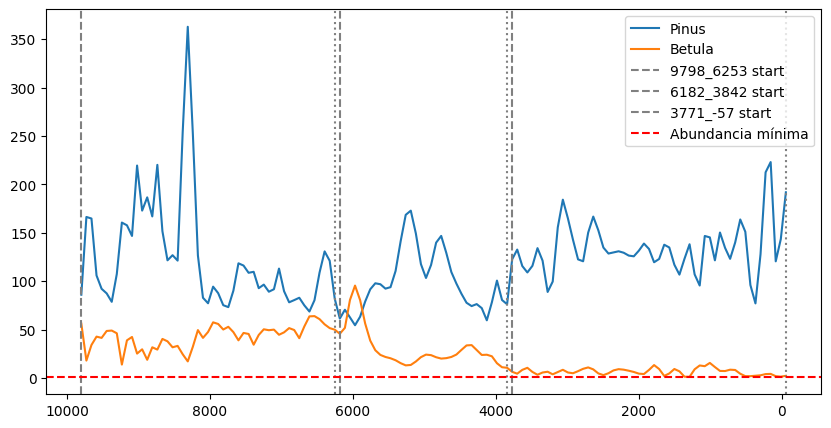


Generando bootstrap...

VENTANA: 9798_6253
Tamaño ventana: 51 observaciones
Especies válidas en ventana: 2
         cal BP       Pinus     Betula
46  6536.666187   80.316014  63.887973
47  6465.767626  108.887827  60.761529
48  6394.869065  130.756949  55.395093
49  6323.970504  121.058866  51.495784
50  6253.071942   81.770361  49.885487

Pinus -> Betula
Original: -0.0333
Bootstrap mean: 0.0009, std: 0.0481


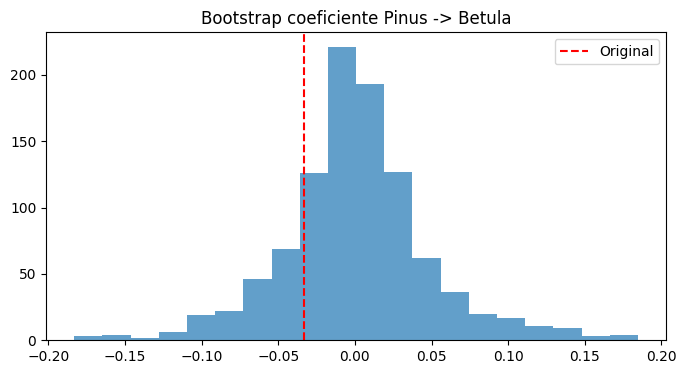

         cal BP     Betula       Pinus
46  6536.666187  63.887973   80.316014
47  6465.767626  60.761529  108.887827
48  6394.869065  55.395093  130.756949
49  6323.970504  51.495784  121.058866
50  6253.071942  49.885487   81.770361

Betula -> Pinus
Original: -0.5911
Bootstrap mean: 0.0140, std: 0.6000


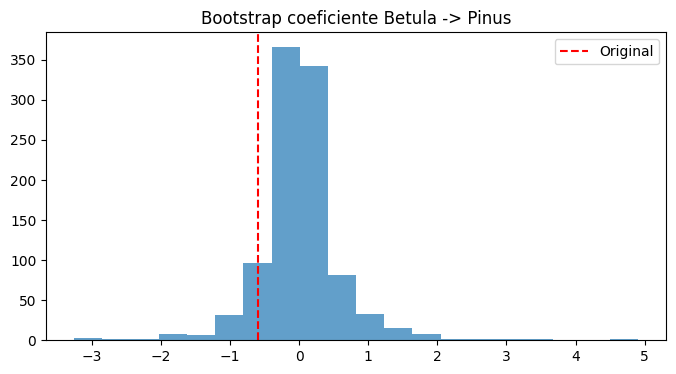

Significativos: 0 (0.00% de válidos)
[[        nan -0.03332737]
 [-0.59109268         nan]]

VENTANA: 6182_3842
Tamaño ventana: 33 observaciones
Especies válidas en ventana: 2
         cal BP       Pinus     Betula
28  4126.115108   59.557841  24.007582
29  4055.216547   78.214155  22.389243
30  3984.317986  100.598278  15.214346
31  3913.419424   80.550978  11.076225
32  3842.520863   76.145185  10.513334

Pinus -> Betula
Original: 0.0336
Bootstrap mean: -0.0022, std: 0.0795


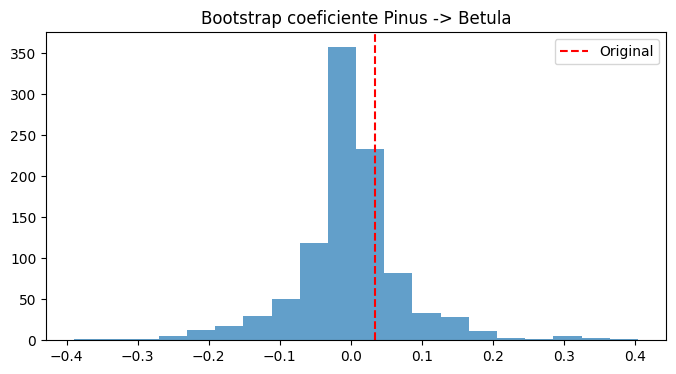

         cal BP     Betula       Pinus
28  4126.115108  24.007582   59.557841
29  4055.216547  22.389243   78.214155
30  3984.317986  15.214346  100.598278
31  3913.419424  11.076225   80.550978
32  3842.520863  10.513334   76.145185

Betula -> Pinus
Original: -0.2236
Bootstrap mean: -0.0002, std: 1.0548


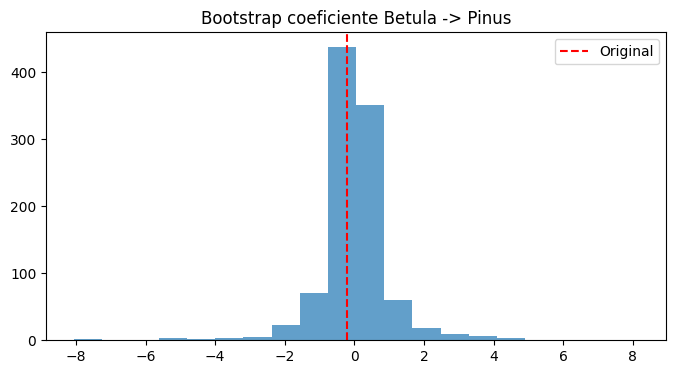

Significativos: 0 (0.00% de válidos)
[[        nan  0.03356928]
 [-0.22358086         nan]]

VENTANA: 3771_-57
Tamaño ventana: 54 observaciones
Especies válidas en ventana: 2
        cal BP       Pinus    Betula
49  226.694245  212.477800  4.000007
50  155.795683  223.052225  4.207760
51   84.897122  120.503643  1.846572
52   13.998561  143.489386  1.299250
53  -56.900000  191.827645  2.242629

Pinus -> Betula
Original: -0.0087
Bootstrap mean: -0.0006, std: 0.0496


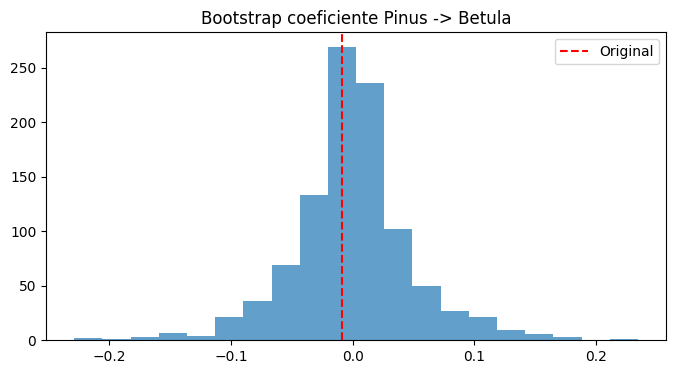

        cal BP    Betula       Pinus
49  226.694245  4.000007  212.477800
50  155.795683  4.207760  223.052225
51   84.897122  1.846572  120.503643
52   13.998561  1.299250  143.489386
53  -56.900000  2.242629  191.827645

Betula -> Pinus
Original: -0.2081
Bootstrap mean: -0.0098, std: 0.4876


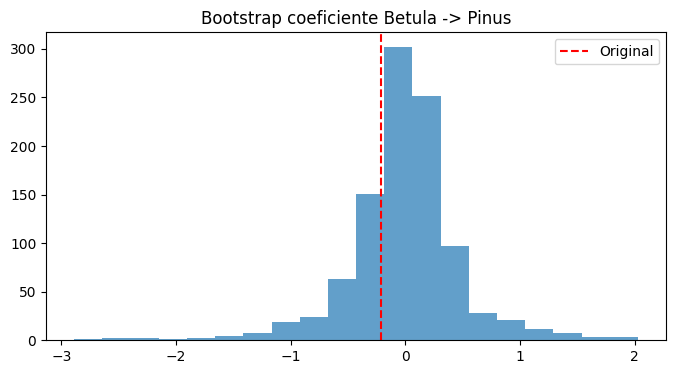

Significativos: 0 (0.00% de válidos)
[[        nan -0.00871976]
 [-0.20814972         nan]]

Proceso terminado correctamente.


In [ ]:
#lo mismo pero para un par de especies concreto

sp_1="Pinus"
sp_2="Betula"
sp_1="Ericaceae"            
sp_2="Iridaceae"

import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 1000
MIN_PRESENCIA = 2
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.5

WINDOWS = {
    "9798_6253": (9798, 6253),
    "6182_3842": (6182, 3842),
    "3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    return (serie > 0).sum() >= MIN_PRESENCIA 


# def bootstrap_estacionario(serie):

    n = len(serie)
    resultado = []

    while len(resultado) < n:

        inicio = np.random.randint(0, n)
        longitud=n+1
        while longitud>n:
            longitud = int(np.random.exponential(scale=n))
        longitud = max(1, min(longitud, n))

        indices = (inicio + np.arange(longitud)) % n
        resultado.extend(serie[indices])

    return np.array(resultado[:n])

#def bootstrap_estacionario(serie):
    n = len(serie)
    # Duplicar la serie para permitir cruce del final sin usar módulo
    serie_period = np.concatenate((serie, serie))
    
    resultado = np.array([])
    
    while len(resultado) < n:
        # Generar longitud de bloque (exponencial con media = n)
        L = int(np.random.exponential(scale=n))
        while L > n:  # Asegurar que L no exceda n
            L = int(np.random.exponential(scale=n))
        
        # Punto de inicio aleatorio (0 a n-1)
        inicio = np.random.randint(0, n)
        
        # Calcular cuántos puntos necesitamos aún
        restantes = n - len(resultado)
        L_actual = min(L, restantes)
        
        # Extraer bloque de serie_period
        # inicio puede estar en la primera copia, pero L_actual puede extenderse a la segunda
        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))
    
    return resultado


def bootstrap_estacionario(serie):
    n = len(serie)
    # Duplicar la serie para permitir cruce del final sin usar módulo
    serie_period = np.concatenate((serie, serie))
    
    resultado = np.array([])
    
    while len(resultado) < n:
        # Generar longitud de bloque (exponencial con media = n)
        L = int(np.random.exponential(scale=n))
        while L > n:  # Asegurar que L no exceda n
            L = int(np.random.exponential(scale=n))
        
        # Punto de inicio aleatorio (0 a n-1)
        inicio = np.random.randint(0, n)
        
        # Calcular cuántos puntos necesitamos aún
        restantes = n - len(resultado)
        L_actual = min(L, restantes)
        
        # Extraer bloque de serie_period
        # inicio puede estar en la primera copia, pero L_actual puede extenderse a la segunda
        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))
    
    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values
    df_boot["Multiplier"] = df["Multiplier"].values


    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot


def extraer_ventana(df, cal_min, cal_max):

    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))

    return df[mask].copy().reset_index(drop=True)


def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:

        x = df[sp1].values
        y = df[sp2].values

        temp = df["Temperatura"]
        mult = df["Multiplier"]

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(temp) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Temp": temp,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        A = results.coefs[0]

        # fila 1 = destino sp2
        # columna 0 = origen sp1
        return A[1][0]
    
    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_delta_mult.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c != "cal BP" and c != "Temperatura" and c != "Multiplier"]

df_original[especies_cols] = df_original[especies_cols].where(
    df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
)

np.random.seed(42)

especies_ejemplo = [sp for sp in [sp_1, sp_2] if sp in especies_cols]

#plotear las series originales de las dos especies en una misma grafica
#añadir lineas verticales indicando las ventanas de tiempo
plt.figure(figsize=(10,5))
for sp in especies_ejemplo:
    plt.plot(df_original["cal BP"], df_original[sp], label=sp)
for window_name, (cmin, cmax) in WINDOWS.items():
    plt.axvline(cmin, color="gray", linestyle="--", label=f"{window_name} start")
    plt.axvline(cmax, color="gray", linestyle=":")
plt.gca().invert_xaxis()
#añadir linea horizontal en abundancia 1
plt.axhline(1, color="red", linestyle="--", label="Abundancia mínima")
plt.legend()
plt.show()

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")

boot_dfs = [
    generar_bootstrap_df(df_original, especies_ejemplo)
    for _ in range(N_BOOTSTRAP)
]



# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)

    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_ejemplo
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)

    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    # boot_windows = [
    #     extraer_ventana(df_b, cmin, cmax)
    #     for df_b in boot_dfs
    # ]

    boot_windows = [
        generar_bootstrap_df(df_w, especies_ejemplo)
        for _ in range(N_BOOTSTRAP)
    ]

    

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))

    total_pairs = 0
    nan_original = 0
    valid_original = 0
    bootstrap_fail = 0

    n_sig = 0
    n_low = 0
    n_high = 0

  



    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):

        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            total_pairs += 1

            print(df_w[["cal BP", sp1, sp2]].tail())

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                nan_original += 1
                continue

            valid_original += 1

            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:

                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)

                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) < N_BOOTSTRAP * 0.5:
                bootstrap_fail += 1
                #continue

            p2_5 = np.percentile(coefs_boot, 2.5)
            p97_5 = np.percentile(coefs_boot, 97.5)

            #printear media y desviación estándar de coefs_boot
            print(f"\n{sp1} -> {sp2}")
            print(f"Original: {coef_original:.4f}")
            print(f"Bootstrap mean: {coefs_boot.mean():.4f}, std: {coefs_boot.std():.4f}")

            if coef_original < p2_5:

                matriz_sig[i, j] = -1
                n_sig += 1
                n_low += 1

            elif coef_original > p97_5:

                matriz_sig[i, j] = 1
                n_sig += 1
                n_high += 1

            #plotear histogramas de la distribución de coeficientes bootstrap para el par de especies
            plt.figure(figsize=(8,4))
            plt.hist(coefs_boot, bins=20, alpha=0.7)
            plt.title(f"Bootstrap coeficiente {sp1} -> {sp2}")
            plt.axvline(coef_original, color="red", linestyle="--", label="Original")
            plt.legend()
            plt.show()


    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    # print("\n--- DIAGNÓSTICO ---")

    # print(f"Pares totales evaluados: {total_pairs}")

    # print(f"Coeficientes originales NaN: {nan_original} "
    #       f"({nan_original/total_pairs*100:.2f}%)")

    # print(f"Coeficientes originales válidos: {valid_original} "
    #       f"({valid_original/total_pairs*100:.2f}%)")

    if valid_original > 0:

        # print(f"Fallos bootstrap: {bootstrap_fail} "
        #       f"({bootstrap_fail/valid_original*100:.2f}% de válidos)")

        # print()

        print(f"Significativos: {n_sig} "
              f"({n_sig/valid_original*100:.2f}% de válidos)")

    #print(f"Cola baja: {n_low}")
    #print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig
    }

    print(resultado["matriz_coeficientes"])


print("\nProceso terminado correctamente.")

In [42]:
coefs_boot.mean()

np.float64(-0.004230660663880909)

In [39]:
df_original["Multiplier"][:50]
#plt.plot(df_original["cal BP"], df_original["Multiplier"])

0     0.060887
1     0.069446
2     0.075816
3     0.071845
4     0.069091
5     0.067687
6     0.073742
7     0.063944
8     0.064709
9     0.068981
10    0.088514
11    0.070448
12    0.071926
13    0.074287
14    0.077122
15    0.090515
16    0.091879
17    0.095445
18    0.099561
19    0.103878
20    0.095995
21    0.092008
22    0.105164
23    0.109564
24    0.089767
25    0.077636
26    0.076386
27    0.068934
28    0.072407
29    0.086038
30    0.073817
31    0.067179
32    0.078949
33    0.084524
34    0.079563
35    0.064909
36    0.068799
37    0.075193
38    0.081876
39    0.078401
40    0.058400
41    0.066328
42    0.071144
43    0.077617
44    0.081963
45    0.055874
46    0.047214
47    0.066583
48    0.062215
49    0.042737
Name: Multiplier, dtype: float64

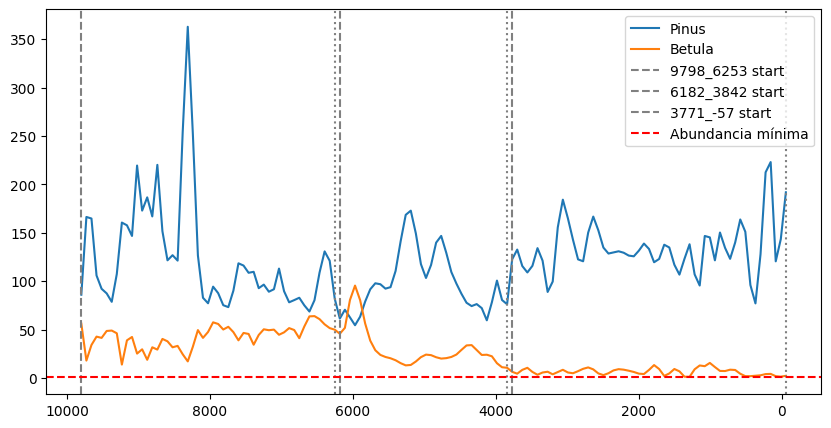


Generando bootstrap...

VENTANA: 9798_6253
Tamaño ventana: 51 observaciones
Especies válidas en ventana: 2

Pinus -> Betula
Original: -0.0231
Bootstrap mean: 0.0020, std: 0.0455


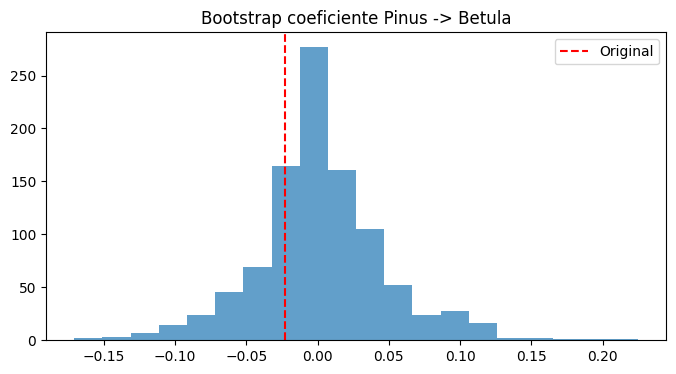


Betula -> Pinus
Original: -0.7477
Bootstrap mean: 0.0181, std: 0.5465


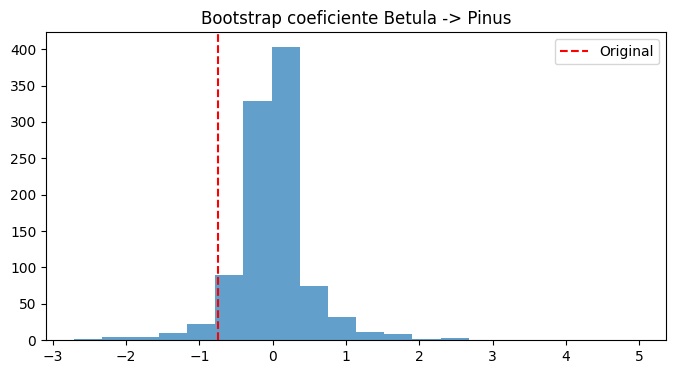

Significativos: 0 (0.00% de válidos)
[[        nan -0.0231324 ]
 [-0.74771877         nan]]

VENTANA: 6182_3842
Tamaño ventana: 33 observaciones
Especies válidas en ventana: 2

Pinus -> Betula
Original: 0.0142
Bootstrap mean: -0.0011, std: 0.0710


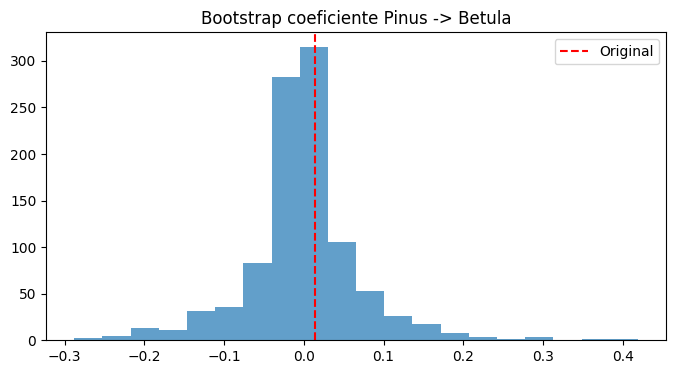


Betula -> Pinus
Original: -0.0044
Bootstrap mean: 0.0000, std: 0.9724


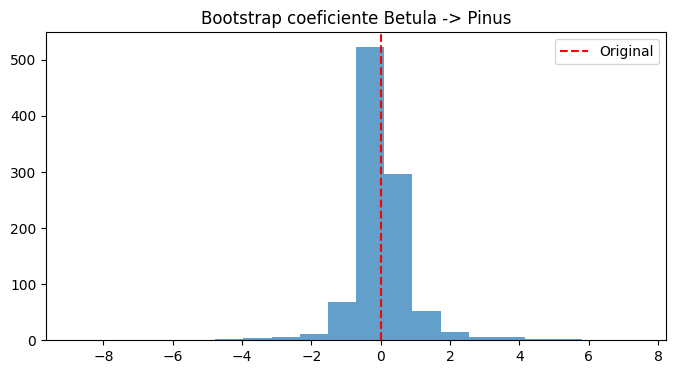

Significativos: 0 (0.00% de válidos)
[[        nan  0.01421238]
 [-0.00441556         nan]]

VENTANA: 3771_-57
Tamaño ventana: 54 observaciones
Especies válidas en ventana: 2

Pinus -> Betula
Original: -0.0085
Bootstrap mean: -0.0008, std: 0.0473


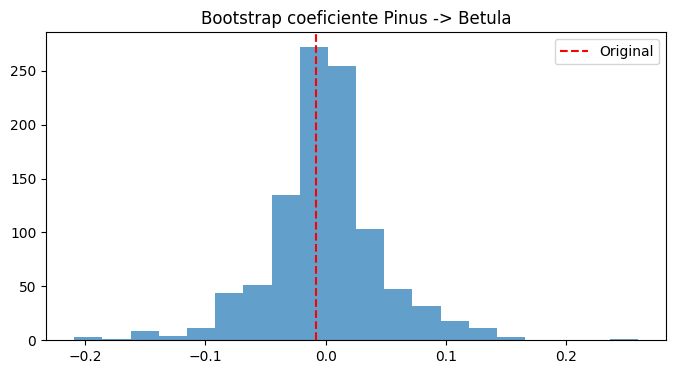


Betula -> Pinus
Original: 0.0367
Bootstrap mean: -0.0098, std: 0.4388


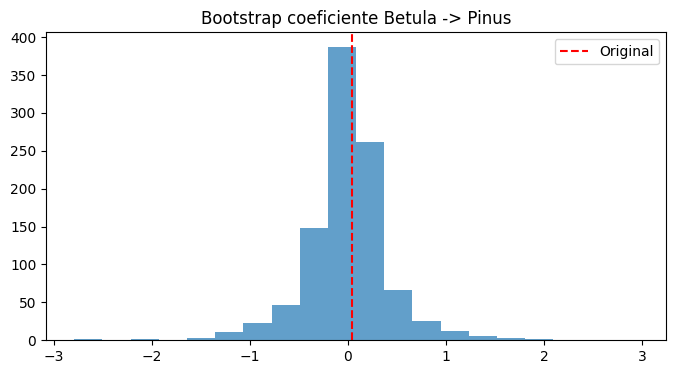

Significativos: 0 (0.00% de válidos)
[[        nan -0.0084575 ]
 [ 0.03671009         nan]]

Proceso terminado correctamente.


In [49]:
#SIN DELTA Y MULTIPLIERS
#lo mismo pero para un par de especies concreto

sp_1="Pinus"
sp_2="Betula"
#sp_1="Ericaceae"            
#sp_2="Iridaceae"

import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 1000
MIN_PRESENCIA = 2
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 1

WINDOWS = {
    "9798_6253": (9798, 6253),
    "6182_3842": (6182, 3842),
    "3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    return (serie > 0).sum() >= MIN_PRESENCIA 


# def bootstrap_estacionario(serie):

    n = len(serie)
    resultado = []

    while len(resultado) < n:

        inicio = np.random.randint(0, n)
        longitud=n+1
        while longitud>n:
            longitud = int(np.random.exponential(scale=n))
        
        longitud = max(1, min(longitud, n))

        indices = (inicio + np.arange(longitud)) % n
        resultado.extend(serie[indices])

    return np.array(resultado[:n])

def bootstrap_estacionario(serie):
    n = len(serie)
    # Duplicar la serie para permitir cruce del final sin usar módulo
    serie_period = np.concatenate((serie, serie))
    
    resultado = np.array([])
    
    while len(resultado) < n:
        # Generar longitud de bloque (exponencial con media = n)
        L = int(np.random.exponential(scale=n))
        while L > n:  # Asegurar que L no exceda n
            L = int(np.random.exponential(scale=n))
        
        # Punto de inicio aleatorio (0 a n-1)
        inicio = np.random.randint(0, n)
        
        # Calcular cuántos puntos necesitamos aún
        restantes = n - len(resultado)
        L_actual = min(L, restantes)
        
        # Extraer bloque de serie_period
        # inicio puede estar en la primera copia, pero L_actual puede extenderse a la segunda
        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))
    
    return resultado


def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot


def extraer_ventana(df, cal_min, cal_max):

    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))

    return df[mask].copy().reset_index(drop=True)


def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:

        x = df[sp1].values
        y = df[sp2].values

        if np.std(x) < MIN_VAR or np.std(y) < MIN_VAR:
            return 0

        data = pd.DataFrame({sp1: x, sp2: y})

        model = VAR(data)
        results = model.fit(maxlags=1)

        A = results.coefs[0]

        # Añade este debug:
        # print("Shape de coefs:", results.coefs[0].shape)  # Debería ser (2,2)
        # print("Tu coeficiente (sp2←sp1):", results.coefs[0][1][0])
        # print("sp1←sp2:", results.coefs[0][0][1])

        return A[1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c != "cal BP"]

df_original[especies_cols] = df_original[especies_cols].where(
    df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
)

np.random.seed(42)

especies_ejemplo = [sp for sp in [sp_1, sp_2] if sp in especies_cols]

#plotear las series originales de las dos especies en una misma grafica
#añadir lineas verticales indicando las ventanas de tiempo
plt.figure(figsize=(10,5))
for sp in especies_ejemplo:
    plt.plot(df_original["cal BP"], df_original[sp], label=sp)
for window_name, (cmin, cmax) in WINDOWS.items():
    plt.axvline(cmin, color="gray", linestyle="--", label=f"{window_name} start")
    plt.axvline(cmax, color="gray", linestyle=":")
plt.gca().invert_xaxis()
#añadir linea horizontal en abundancia 1
plt.axhline(1, color="red", linestyle="--", label="Abundancia mínima")
plt.legend()
plt.show()

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")

boot_dfs = [
    generar_bootstrap_df(df_original, especies_ejemplo)
    for _ in range(N_BOOTSTRAP)
]



# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)

    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_ejemplo
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)

    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    boot_windows = [
        extraer_ventana(df_b, cmin, cmax)
        for df_b in boot_dfs
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))

    total_pairs = 0
    nan_original = 0
    valid_original = 0
    bootstrap_fail = 0

    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):

        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            total_pairs += 1

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                nan_original += 1
                continue

            valid_original += 1

            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:

                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)

                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) < N_BOOTSTRAP * 0.5:
                bootstrap_fail += 1
                #continue

            p2_5 = np.percentile(coefs_boot, 2.5)
            p97_5 = np.percentile(coefs_boot, 97.5)

            #printear media y desviación estándar de coefs_boot
            print(f"\n{sp1} -> {sp2}")
            print(f"Original: {coef_original:.4f}")
            print(f"Bootstrap mean: {coefs_boot.mean():.4f}, std: {coefs_boot.std():.4f}")

            if coef_original < p2_5:

                matriz_sig[i, j] = -1
                n_sig += 1
                n_low += 1

            elif coef_original > p97_5:

                matriz_sig[i, j] = 1
                n_sig += 1
                n_high += 1

            #plotear histogramas de la distribución de coeficientes bootstrap para el par de especies
            plt.figure(figsize=(8,4))
            plt.hist(coefs_boot, bins=20, alpha=0.7)
            plt.title(f"Bootstrap coeficiente {sp1} -> {sp2}")
            plt.axvline(coef_original, color="red", linestyle="--", label="Original")
            plt.legend()
            plt.show()


    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    # print("\n--- DIAGNÓSTICO ---")

    # print(f"Pares totales evaluados: {total_pairs}")

    # print(f"Coeficientes originales NaN: {nan_original} "
    #       f"({nan_original/total_pairs*100:.2f}%)")

    # print(f"Coeficientes originales válidos: {valid_original} "
    #       f"({valid_original/total_pairs*100:.2f}%)")

    if valid_original > 0:

        # print(f"Fallos bootstrap: {bootstrap_fail} "
        #       f"({bootstrap_fail/valid_original*100:.2f}% de válidos)")

        # print()

        print(f"Significativos: {n_sig} "
              f"({n_sig/valid_original*100:.2f}% de válidos)")

    #print(f"Cola baja: {n_low}")
    #print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig
    }

    print(resultado["matriz_coeficientes"])


print("\nProceso terminado correctamente.")

In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 1

WINDOWS = {
    "9798_6253": (9798, 6253)
    #"6182_3842": (6182, 3842)
    #"3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    #return (serie > 0).sum() >= MIN_PRESENCIA and serie.nunique() > 1
    return (serie > 0).sum() >= MIN_PRESENCIA 


def bootstrap_univariante_exp(serie):

    n = len(serie)
    resultado = []

    while len(resultado) < n:

        inicio = np.random.randint(0, n)

        longitud = int(np.random.exponential(scale=n))
        longitud = max(1, min(longitud, n))

        indices = (inicio + np.arange(longitud)) % n
        resultado.extend(serie[indices])

    return np.array(resultado[:n])


def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values

    for col in columnas:
        df_boot[col] = bootstrap_univariante_exp(df[col].values)

    return df_boot


def extraer_ventana(df, cal_min, cal_max):

    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))

    return df[mask].copy().reset_index(drop=True)


def coef_sp1_a_sp2_condicional(df, sp1, sp2, return_zero_on_fail=True):
    try:
        x = df[sp1].values
        y = df[sp2].values

        if np.std(x) < MIN_VAR or np.std(y) < MIN_VAR:
            return 0 if return_zero_on_fail else np.nan

        # Opcional: estandarizar
        # x = (x - x.mean()) / x.std()
        # y = (y - y.mean()) / y.std()

        data = pd.DataFrame({sp1: x, sp2: y})
        model = VAR(data)
        results = model.fit(maxlags=1)
        
        coef = results.coefs[0][1][0]
        
        return coef

    except:
        return (0) if return_zero_on_fail else (np.nan)

# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam.pkl", "rb") as f:
    df_original = pickle.load(f)

#invertir el orden temporal para que vaya de más antiguo a más reciente (cal BP va de mayor a menor)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c != "cal BP"]

df_original[especies_cols] = df_original[especies_cols].where(
    df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
)

especies_globales = [
    sp for sp in especies_cols
    if es_serie_valida(df_original[sp])
]

print(f"Especies válidas en serie completa: {len(especies_globales)}")

np.random.seed(42)

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")

boot_dfs = [
    generar_bootstrap_df(df_original, especies_globales)
    for _ in range(N_BOOTSTRAP)
]

print("Bootstrap generados.")

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)

    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_globales
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)

    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    # diagnóstico varianzas
    stds = df_w[especies_ventana].std()

    print("\nVarianzas mínimas:")
    print(stds.sort_values().head(10))

    boot_windows = [
        extraer_ventana(df_b, cmin, cmax)
        for df_b in boot_dfs
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))

    total_pairs = 0
    nan_original = 0
    valid_original = 0
    bootstrap_fail = 0

    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):

        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            total_pairs += 1

            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                nan_original += 1
                continue

            valid_original += 1

            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:

                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)

                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) < N_BOOTSTRAP * 0.5:
                bootstrap_fail += 1
                #continue

            p2_5 = np.percentile(coefs_boot, 2.5)
            p97_5 = np.percentile(coefs_boot, 97.5)

            if coef_original < p2_5:

                matriz_sig[i, j] = -1
                n_sig += 1
                n_low += 1

            elif coef_original > p97_5:

                matriz_sig[i, j] = 1
                n_sig += 1
                n_high += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    print("\n--- DIAGNÓSTICO ---")

    print(f"Pares totales evaluados: {total_pairs}")

    print(f"Coeficientes originales NaN: {nan_original} "
          f"({nan_original/total_pairs*100:.2f}%)")

    print(f"Coeficientes originales válidos: {valid_original} "
          f"({valid_original/total_pairs*100:.2f}%)")

    if valid_original > 0:

        print(f"Fallos bootstrap: {bootstrap_fail} "
              f"({bootstrap_fail/valid_original*100:.2f}% de válidos)")

        print()

        print(f"Significativos: {n_sig} "
              f"({n_sig/valid_original*100:.2f}% de válidos)")

    print(f"Cola baja: {n_low}")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig
    }

    nombre_archivo = f"red_granger_{window_name}.pkl"

    with open(nombre_archivo, "wb") as f:
        pickle.dump(resultado, f)

    print(f"\nGuardado: {nombre_archivo}")

print("\nProceso terminado correctamente.")